## <span style="color:#db7d60">Purpose</span>

The goal of this notebook is to track in-training models to see if we should resume or stop training for them.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
import json
import pickle
from collections import Counter, defaultdict
from types import SimpleNamespace
from itertools import islice
from pathlib import Path
# Math
import math
import numpy as np
import pandas as pd
from numba import njit, float64, types
from numba.experimental import jitclass
from numba.typed import Dict
from scipy.signal import savgol_filter
from numerize import numerize
# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from particle import Particle
import vector
import jetnet
import jetnet.evaluation

# pUtil needs to be loaded from the root directory
parent_dir = Path().resolve().parent
root_dir = Path().resolve().parent.parent
sys.path.insert(0, str(parent_dir))
sys.path.insert(0, str(root_dir))

# particleGPT
import pUtil
import data_manager
from analysis_common import *
import analysis_v2 as analv2

#### Set basic themeing and display options for optimal display of information

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option("display.float_format", "{:,.0f}".format)

# Set use_text=True if a latex installation is avaliable.
analv2.plotting_v2.set_publication_style(base_fontsize=10, dpi=100, save_dpi=600, use_tex=False)

# We want larger fonts for these figures
analv2.plotting_v2.fontsize_ticks = 14
analv2.plotting_v2.axes_fontsize = 12

<Figure size 640x480 with 0 Axes>

## <span style="color:#db7d60">Main</span>

Functions for nice display of compute time

In [3]:
def ms_to_days_hours(ms):
    total_hours = round(ms / 1000 / 60 / 60)
    print(total_hours)
    days = total_hours // 24
    hours = total_hours % 24
    
    if days > 0:
        return f"{days}d {hours}h"
    else:
        return f"{hours}h"

def ms_to_days_hours_vec(ms):
    arr = np.asarray(ms, dtype=float)

    total_hours = np.rint(arr / 1000 / 3600).astype(np.int64)
    days = total_hours // 24
    hours = total_hours % 24

    days_str = days.astype(str)
    hours_str = hours.astype(str)

    out = np.where(
        days > 0,
        np.char.add(np.char.add(np.char.add(days_str, "d "), hours_str), "h"),
        np.char.add(hours_str, "h"),
    )

    if np.isscalar(ms):
        return out.item()
    if isinstance(ms, pd.Series):
        return pd.Series(out, index=ms.index)
    return out

### Tracking matrix

Tracking all the models we require for result 2.

In [4]:
model_names_and_labels = {
    'model_exp11_100k_lr1': '16.6M - 20M',
    'model_exp11_100k_lr1_tp6': '16.6M - 39M',
    'model_exp11_100k_lr1_tp4': '16.6M - 70M',
    'model_exp11_100k_lr1_tp3': '16.6M - 108M',
    'model_exp11_100k_lr1_tp2': '16.6M - 208M',
    'model_exp11_500k_lr1': '83M - 20M',
    'model_exp11_500k_lr1_tp4': '83M - 79M',
    'model_exp11_500k_lr1_tp6': '83M - 39M',
    'model_exp11_1M_lr1': '166M - 20M',
    'model_exp11_1M_lr1_tp3': '166M - 108M', 
    'model_exp11_1M_lr1_tp4': '166M - 76M', 
    'model_exp11_1M_lr1_tp5': '166M - 611M', 
    'model_exp11_1M_lr1_tp6': '166M - 39M', 
    'model_exp11_2M_lr1': '332M - 20M',
    'model_exp11_2M_lr1_tp3': '332M - 108M',
    'model_exp11_2M_lr1_tp4': '332M - 76M',
    'model_exp11_2M_lr1_tp5': '332M - 611M',
    'model_exp11_2M_lr1_tp6': '332M - 39M',
    'model_exp11_5M_lr1': '830M - 20M',
    'model_exp11_5M_lr1_tp2': '830M - 208M',
    'model_exp11_5M_lr1_tp3': '830M - 108M',
    'model_exp11_5M_lr1_tp4': '830M - 76M',
    'model_exp11_5M_lr1_tp6': '830M - 39M',
    'model_10M_9_exp9_vdimlr_1': '1.47B - 20M',
    'model_exp11_9M_lr1_tp2': '1.47B - 208M',
    'model_exp11_9M_lr1_tp3': '1.47B - 108M',
    'model_exp11_9M_lr1_tp4': '1.47B - 76M',
    'model_exp11_9M_lr1_tp6': '1.47B - 39M',
    'model_exp11_9M_lr1_tp5': '1.47B - 611M',
    'model_exp11_22M_lr1_tp1': '3.8B - 20M',
    'model_exp11_22M_lr1_tp2': '3.8B - 208M',
    'model_exp11_22M_lr1_tp3': '3.8B - 108M',
    'model_exp11_22M_lr1_tp4': '3.8B - 76M',
    'model_exp11_22M_lr1_tp6': '3.8B - 39M',
    'model_exp11_22M_lr1_tp5': '3.8B - 611M',
    'model_exp11_45M_lr1_tp1': 'N/A B - 20M',
    'model_exp11_45M_lr1_tp6': 'N/A B - 39M',
    'model_exp11_45M_lr1_tp4': 'N/A B - 76M',
    'model_exp11_45M_lr1_tp3': 'N/A B - 108M',
    'model_exp11_45M_lr1_tp2': 'N/A B - 208M',
    'model_exp11_45M_lr1_tp5': 'N/A B - 611M'
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())

df1 = analv2.tables.get_default_df(model_names)
df1["compute"] = df1["num_params"] * df1["batch_size"] * df1["iters_saved"]


In [5]:
def fmt_tokens(x):
    if x >= 1e9:
        return f"{x/1e9:.2f}B"
    else:
        return f"{x/1e6:.1f}M"

matrix = df1.pivot(index="num_params", columns="num_train_tokens", values="model_name")
matrix.columns = matrix.columns.map(fmt_tokens)
matrix.index = matrix.index.map(fmt_tokens)
display(matrix)

num_train_tokens,16.6M,83.0M,166.0M,332.0M,830.0M,1.47B,3.78B,7.57B
num_params,,,,,,,,
20.1M,model_exp11_100k_lr1,model_exp11_500k_lr1,model_exp11_1M_lr1,model_exp11_2M_lr1,model_exp11_5M_lr1,model_10M_9_exp9_vdimlr_1,model_exp11_22M_lr1_tp1,model_exp11_45M_lr1_tp1
39.0M,model_exp11_100k_lr1_tp6,model_exp11_500k_lr1_tp6,model_exp11_1M_lr1_tp6,model_exp11_2M_lr1_tp6,model_exp11_5M_lr1_tp6,model_exp11_9M_lr1_tp6,model_exp11_22M_lr1_tp6,model_exp11_45M_lr1_tp6
70.5M,model_exp11_100k_lr1_tp4,model_exp11_500k_lr1_tp4,model_exp11_1M_lr1_tp4,model_exp11_2M_lr1_tp4,model_exp11_5M_lr1_tp4,model_exp11_9M_lr1_tp4,model_exp11_22M_lr1_tp4,model_exp11_45M_lr1_tp4
108.3M,model_exp11_100k_lr1_tp3,NaN,model_exp11_1M_lr1_tp3,model_exp11_2M_lr1_tp3,model_exp11_5M_lr1_tp3,model_exp11_9M_lr1_tp3,model_exp11_22M_lr1_tp3,model_exp11_45M_lr1_tp3
209.0M,model_exp11_100k_lr1_tp2,NaN,NaN,NaN,model_exp11_5M_lr1_tp2,model_exp11_9M_lr1_tp2,model_exp11_22M_lr1_tp2,model_exp11_45M_lr1_tp2
611.7M,NaN,NaN,model_exp11_1M_lr1_tp5,model_exp11_2M_lr1_tp5,NaN,model_exp11_9M_lr1_tp5,model_exp11_22M_lr1_tp5,model_exp11_45M_lr1_tp5


In [6]:
disp_df = df1[['model_name', 'iters_saved', 'min_saved_train_loss', 'min_saved_val_loss', 'num_train_tokens', 'num_params', 'compute', 'compute_time_saved']].copy()
disp_df['compute_time_saved_nice'] = ms_to_days_hours_vec(disp_df['compute_time_saved'])

sorting_key = 'num_train_tokens'
print(f"Sorted by: {sorting_key}")
display(disp_df.sort_values(by=[sorting_key, 'num_params'], ascending=True)
    .style.format({"num_train_tokens": "{:,}", "num_params": "{:,}" , "compute": "{:,}"}))

Sorted by: num_train_tokens


,model_name,iters_saved,min_saved_train_loss,min_saved_val_loss,num_train_tokens,num_params,compute,compute_time_saved,compute_time_saved_nice
0,model_exp11_100k_lr1,500,4.617033,4.753753,"16,600,000","20,148,224","1,289,486,336,000",1313655.804157,0h
1,model_exp11_100k_lr1_tp6,500,4.642526,4.720204,"16,600,000","39,028,736","2,497,839,104,000",1589963.849068,0h
2,model_exp11_100k_lr1_tp4,500,4.661116,4.738809,"16,600,000","70,496,256","4,511,760,384,000",3001123.470068,1h
3,model_exp11_100k_lr1_tp3,500,4.650380,4.729704,"16,600,000","108,257,280","6,928,465,920,000",6598092.458248,2h
4,model_exp11_100k_lr1_tp2,600,4.654042,4.762797,"16,600,000","208,953,344","16,047,616,819,200",16458852.971077,5h
5,model_exp11_500k_lr1,2000,4.515970,4.626153,"83,000,000","20,148,224","5,157,945,344,000",5078752.273798,1h
7,model_exp11_500k_lr1_tp6,2000,4.477430,4.606902,"83,000,000","39,028,736","9,991,356,416,000",6294346.179008,2h
6,model_exp11_500k_lr1_tp4,1750,4.500299,4.617005,"83,000,000","70,496,256","15,791,161,344,000",10441625.570774,3h
8,model_exp11_1M_lr1,4250,4.504503,4.558721,"166,000,000","20,148,224","10,960,633,856,000",10832239.154816,3h
12,model_exp11_1M_lr1_tp6,3250,4.475439,4.551252,"166,000,000","39,028,736","16,235,954,176,000",11152388.391972,3h


### Tracking bubble chart

In [7]:
model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())

df = analv2.tables.get_default_df(model_names)
df["compute"] = df["num_params"] * df["batch_size"] * df["iters_saved"]

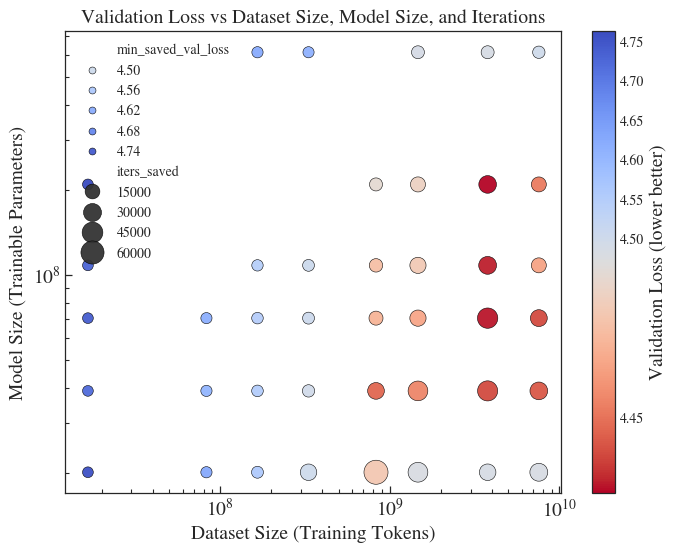

In [8]:
analv2.plotting_v2.fontsize_ticks = 14
analv2.plotting_v2.axes_fontsize = 14
analv2.plotting_v2.fontsize_legend = 14

plot_df = df.copy()

norm = mcolors.TwoSlopeNorm(
    vmin=plot_df["min_saved_val_loss"].min(),
    vcenter=4.47,
    vmax=plot_df["min_saved_val_loss"].max()
)

fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(
    ax=ax,
    data=plot_df, x="num_train_tokens", y="num_params", hue="min_saved_val_loss", hue_norm=norm, size="iters_saved", sizes=(60, 300),
    palette="coolwarm_r", edgecolor="black", linewidth=0.4, alpha=0.95, legend="brief",
)
ax.set_xscale("log")
ax.set_yscale("log")

sm = cm.ScalarMappable(cmap="coolwarm_r", norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Validation Loss (lower better)", fontsize=analv2.plotting_v2.fontsize_legend)

ax.set_xlabel("Dataset Size (Training Tokens)", fontsize=analv2.plotting_v2.axes_fontsize)
ax.set_ylabel("Model Size (Trainable Parameters)", fontsize=analv2.plotting_v2.axes_fontsize)
ax.set_title("Validation Loss vs Dataset Size, Model Size, and Iterations", fontsize=analv2.plotting_v2.axes_fontsize)

ax.tick_params(axis='both', labelsize=analv2.plotting_v2.fontsize_ticks)

plt.grid(False)
plt.show()

Based on the previous cell's output, the 611M models (top row) needs to be trained longer

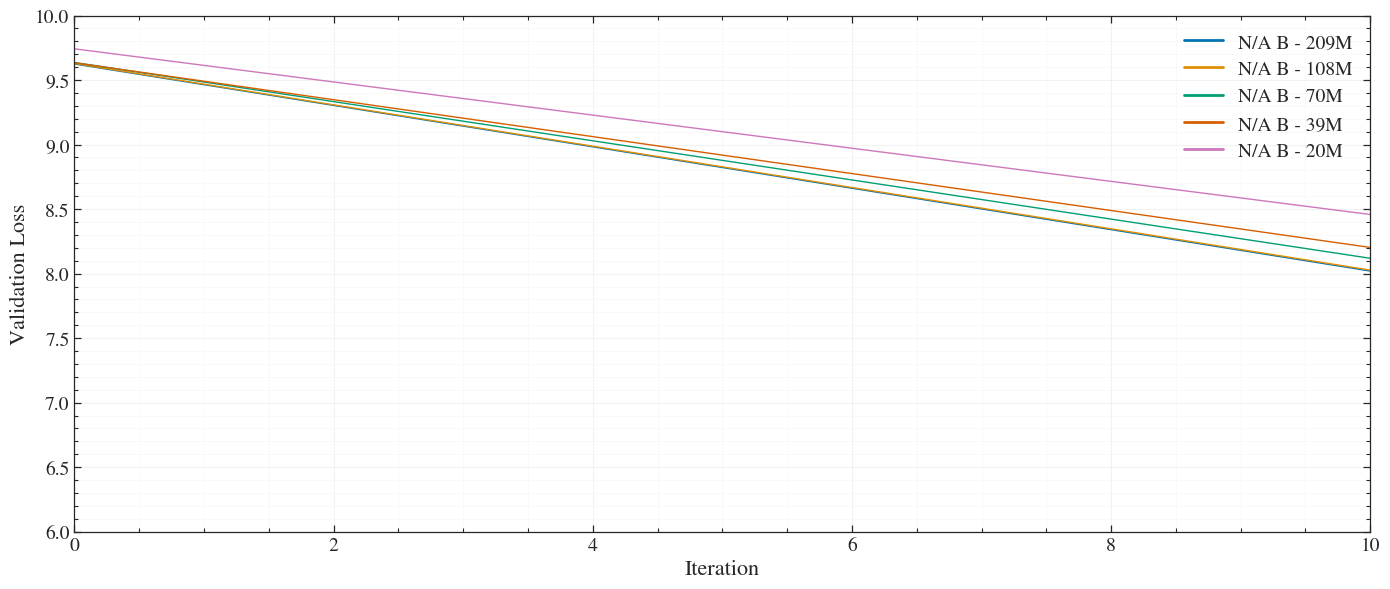

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [9]:
model_names_and_labels = {
    'model_exp11_100k_lr1_tp2': 'N/A B - 209M',
    'model_exp11_100k_lr1_tp3': 'N/A B - 108M',
    'model_exp11_100k_lr1_tp4': 'N/A B - 70M',
    'model_exp11_100k_lr1_tp6': 'N/A B - 39M',
    'model_exp11_100k_lr1': 'N/A B - 20M',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())

# This API is self-explanatory
analv2.plotting_v2.plot_training_run(model_names, model_legend_title=model_labels, show_val_loss=True, use_log=False, y_lim=(6, 10), x_lim=(0, 10), figsize=(14, 6))

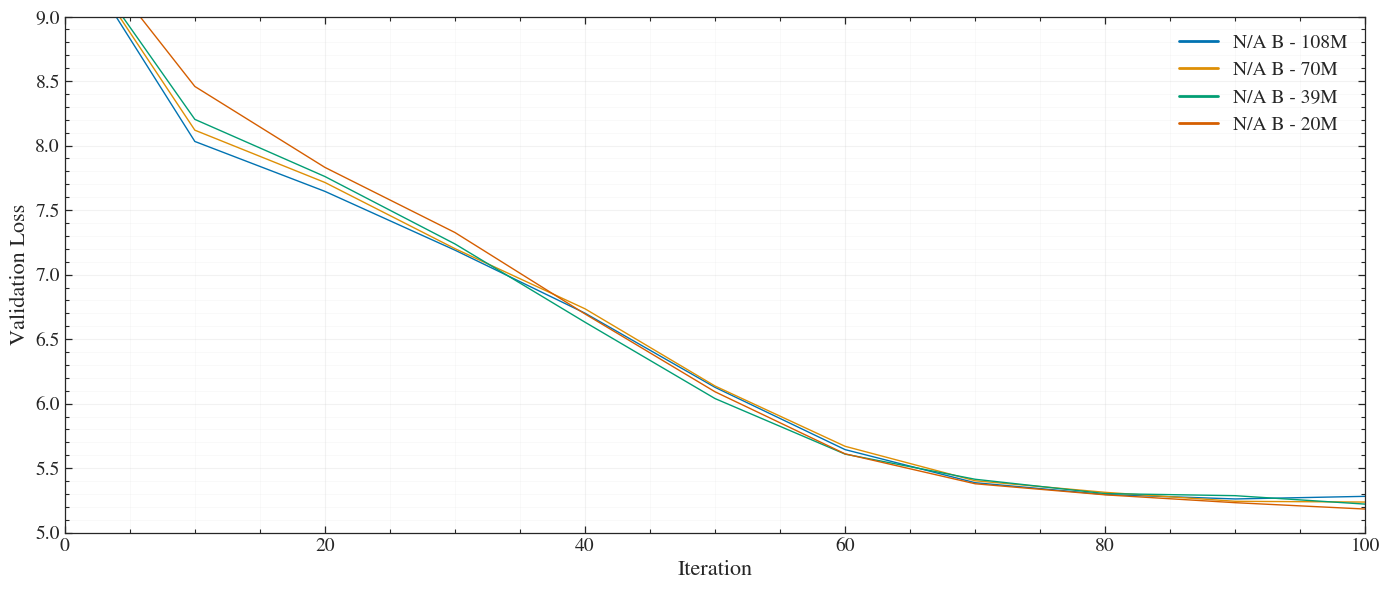

(<Figure size 1400x600 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation Loss'>)

In [10]:
model_names_and_labels = {
    'model_exp11_1M_lr1_tp3': 'N/A B - 108M',
    'model_exp11_1M_lr1_tp4': 'N/A B - 70M',
    'model_exp11_1M_lr1_tp6': 'N/A B - 39M',
    'model_exp11_1M_lr1': 'N/A B - 20M',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())
analv2.plotting_v2.plot_training_run(model_names, model_legend_title=model_labels, show_val_loss=True, use_log=False, y_lim=(5, 9), x_lim=(0, 100), figsize=(14, 6))